# FBA1013 CA1 — Fixed Income Investment Brief
**Group Assignment | MSc Finance | Dublin City University**

### What this notebook does
1. **Bond Data** — set up all 13 US Treasury bonds from Appendix A
2. **Bond Pricing** — calculate clean price, Macaulay duration, Modified duration
3. **NSS Yield Curve** — fit a smooth curve through the 4 known yield points
4. **Yield Curve Scenarios** — how the curve shifts under different rate environments
5. **Price Sensitivity** — how much each bond's price changes when rates move
6. **Portfolio Recommendation** — a suggested allocation for the $50m pool
7. **Immunisation** — protect the $8m liability due in 2 years from rate risk

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from datetime import date

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
print('Libraries loaded.')

Libraries loaded.


---
## Section 1 — Bond Data
We enter all 13 US Treasury bonds from Appendix A.  
**TTM (Time to Maturity)** = years remaining until the bond matures, from today's settlement date.  
All bonds mature on **31 December** of their stated year and pay coupons **semi-annually**.

In [2]:
settlement = date(2026, 4, 6)

bonds_raw = [
    (0.000, 2026), (0.010, 2027), (0.020, 2028), (0.022, 2029),
    (0.020, 2031), (0.022, 2032), (0.022, 2035), (0.030, 2040),
    (0.035, 2046), (0.036, 2048), (0.030, 2050), (0.029, 2051),
    (0.030, 2061),
]

bonds = pd.DataFrame(bonds_raw, columns=['coupon', 'maturity_year'])
bonds['maturity_date'] = bonds['maturity_year'].apply(lambda y: date(y, 12, 31))
bonds['ttm']   = bonds['maturity_date'].apply(lambda m: (m - settlement).days / 365.25)
bonds['label'] = bonds.apply(lambda r: f"{r['coupon']*100:.1f}% UST {r['maturity_year']}", axis=1)

print(bonds[['label','coupon','maturity_year','ttm']].rename(
    columns={'label':'Bond','coupon':'Coupon','maturity_year':'Maturity','ttm':'TTM (yrs)'}
).to_string(index=False))

         Bond  Coupon  Maturity  TTM (yrs)
0.0% UST 2026   0.000      2026   0.736482
1.0% UST 2027   0.010      2027   1.735797
2.0% UST 2028   0.020      2028   2.737851
2.2% UST 2029   0.022      2029   3.737166
2.0% UST 2031   0.020      2031   5.735797
2.2% UST 2032   0.022      2032   6.737851
2.2% UST 2035   0.022      2035   9.735797
3.0% UST 2040   0.030      2040  14.737851
3.5% UST 2046   0.035      2046  20.736482
3.6% UST 2048   0.036      2048  22.737851
3.0% UST 2050   0.030      2050  24.736482
2.9% UST 2051   0.029      2051  25.735797
3.0% UST 2061   0.030      2061  35.737166


---
## Section 2 — Bond Pricing Functions

**Bond Price** = PV of all future coupons + PV of face value, discounted at the YTM.  

**Macaulay Duration** = weighted average time until you receive your money back (in years).  
A bond maturing in 5 years might have a duration of 4.3 years because coupons arrive sooner.

**Modified Duration** = Macaulay Duration / (1 + YTM/2).  
Tells you: *for every 1% rise in yield, price falls by approximately ModDur %.*

In [3]:
def bond_price(face, coupon_rate, ytm, ttm, freq=2):
    n = round(ttm * freq)
    c = face * coupon_rate / freq
    r = ytm / freq
    if r == 0:
        return c * n + face
    return c * (1 - (1 + r)**(-n)) / r + face / (1 + r)**n

def macaulay_duration(face, coupon_rate, ytm, ttm, freq=2):
    n = round(ttm * freq)
    c = face * coupon_rate / freq
    r = ytm / freq
    total_pv = weighted_pv = 0
    for t in range(1, n + 1):
        cf = c if t < n else c + face
        pv = cf / (1 + r)**t
        total_pv    += pv
        weighted_pv += (t / freq) * pv
    return weighted_pv / total_pv

def modified_duration(face, coupon_rate, ytm, ttm, freq=2):
    return macaulay_duration(face, coupon_rate, ytm, ttm, freq) / (1 + ytm / freq)

print('Pricing functions defined.')

Pricing functions defined.


---
## Section 3 — Nelson-Siegel-Svensson (NSS) Yield Curve

We only know yields at 4 maturities (1yr, 2yr, 15yr, 25yr) from Appendix C.  
We need yields at **every** maturity to price all 13 bonds.

The **NSS model** fits a smooth curve through the known points using 6 parameters.  
We use `scipy.optimize.minimize` to find the best-fit parameters.

In [4]:
known_mat    = np.array([1, 2, 15, 25])
known_yields = np.array([0.0198, 0.0180, 0.0350, 0.0375])

def nss_yield(t, b0, b1, b2, b3, l1, l2):
    t  = np.maximum(t, 1e-6)
    f1 = (1 - np.exp(-t / l1)) / (t / l1)
    f2 = f1 - np.exp(-t / l1)
    f3 = (1 - np.exp(-t / l2)) / (t / l2) - np.exp(-t / l2)
    return b0 + b1 * f1 + b2 * f2 + b3 * f3

def nss_loss(params):
    b0, b1, b2, b3, l1, l2 = params
    return np.sum((nss_yield(known_mat, b0, b1, b2, b3, l1, l2) - known_yields)**2)

x0     = [0.04, -0.02, 0.01, 0.01, 2.0, 5.0]
bounds = [(0.001,0.15),(-0.15,0.15),(-0.15,0.15),(-0.15,0.15),(0.1,30),(0.1,30)]
res    = minimize(nss_loss, x0, bounds=bounds, method='L-BFGS-B')
b0, b1, b2, b3, l1, l2 = res.x

print(f'Converged: {res.success}')
print(f'Params: b0={b0:.4f}, b1={b1:.4f}, b2={b2:.4f}, b3={b3:.4f}, l1={l1:.4f}, l2={l2:.4f}')
print()
print(f'{"Maturity":<10} {"Known":>10} {"Fitted":>10} {"Error bps":>12}')
for m, y in zip(known_mat, known_yields):
    fit = nss_yield(m, b0, b1, b2, b3, l1, l2)
    print(f'{m:>5} yr     {y*100:>8.3f}%   {fit*100:>8.3f}%   {(fit-y)*10000:>+10.2f}')

Converged: True
Params: b0=0.0397, b1=-0.0134, b2=-0.0617, b3=0.0196, l1=2.0022, l2=5.0005

Maturity        Known     Fitted    Error bps
    1 yr        1.980%      1.980%        +0.00
    2 yr        1.800%      1.800%        -0.02
   15 yr        3.500%      3.500%        +0.02
   25 yr        3.750%      3.750%        -0.01


In [5]:
full_mats   = np.array([1,2,3,4,5,8,10,15,20,25,30])
full_yields = nss_yield(full_mats, b0, b1, b2, b3, l1, l2)

print(f'{"Maturity (yrs)":<16} {"Yield (%)":>10}   {"Source":>16}')
print('-'*46)
for m, y in zip(full_mats, full_yields):
    src = 'known' if m in known_mat else 'interpolated'
    print(f'{m:<16} {y*100:>10.3f}%   {src:>16}')

Maturity (yrs)    Yield (%)             Source
----------------------------------------------
1                     1.980%              known
2                     1.800%              known
3                     1.861%       interpolated
4                     2.031%       interpolated
5                     2.241%       interpolated
8                     2.826%       interpolated
10                    3.106%       interpolated
15                    3.500%              known
20                    3.669%       interpolated
25                    3.750%              known
30                    3.795%       interpolated


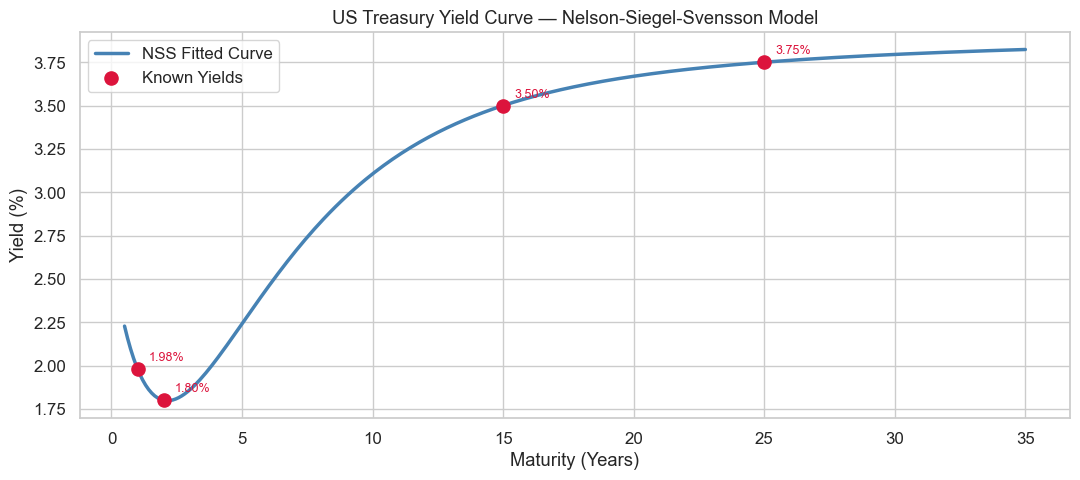

In [6]:
t_range = np.linspace(0.5, 35, 300)
y_range = nss_yield(t_range, b0, b1, b2, b3, l1, l2)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(t_range, y_range * 100, color='steelblue', linewidth=2.5, label='NSS Fitted Curve')
ax.scatter(known_mat, known_yields * 100, color='crimson', s=90, zorder=5, label='Known Yields')
for m, y in zip(known_mat, known_yields):
    ax.annotate(f'{y*100:.2f}%', (m, y*100), xytext=(8,6), textcoords='offset points',
                fontsize=9, color='crimson')
ax.set_xlabel('Maturity (Years)')
ax.set_ylabel('Yield (%)')
ax.set_title('US Treasury Yield Curve — Nelson-Siegel-Svensson Model')
ax.legend()
plt.tight_layout()
plt.show()

---
## Section 4 — Price All Bonds Using NSS Yields

In [7]:
face = 100
rows = []
for _, row in bonds.iterrows():
    ttm   = row['ttm']
    ytm   = nss_yield(ttm, b0, b1, b2, b3, l1, l2)
    price = bond_price(face, row['coupon'], ytm, ttm)
    mac   = macaulay_duration(face, row['coupon'], ytm, ttm)
    mod   = modified_duration(face, row['coupon'], ytm, ttm)
    rows.append({'Bond': row['label'], 'TTM (yrs)': round(ttm,2),
                 'YTM (%)': round(ytm*100,3), 'Price ($)': round(price,4),
                 'Mac Dur (yrs)': round(mac,4), 'Mod Dur': round(mod,4)})

bond_res = pd.DataFrame(rows)
print(bond_res.to_string(index=False))

         Bond  TTM (yrs)  YTM (%)  Price ($)  Mac Dur (yrs)  Mod Dur
0.0% UST 2026       0.74    2.094    98.9640         0.5000   0.4948
1.0% UST 2027       1.74    1.817    98.7968         1.4925   1.4791
2.0% UST 2028       2.74    1.830   100.4135         2.4511   2.4289
2.2% UST 2029       3.74    1.981   100.7383         3.3883   3.3551
2.0% UST 2031       5.74    2.399    97.9571         5.2322   5.1702
2.2% UST 2032       6.74    2.601    97.6144         6.0859   6.0078
2.2% UST 2035       9.74    3.074    92.8467         8.5830   8.4531
3.0% UST 2040      14.74    3.487    94.4947        11.7712  11.5695
3.5% UST 2046      20.74    3.685    97.3615        14.7083  14.4423
3.6% UST 2048      22.74    3.720    98.1867        15.5352  15.2516
3.0% UST 2050      24.74    3.747    88.0958        16.9920  16.6795
2.9% UST 2051      25.74    3.758    86.0025        17.5313  17.2080
3.0% UST 2061      35.74    3.827    84.0211        20.7558  20.3661


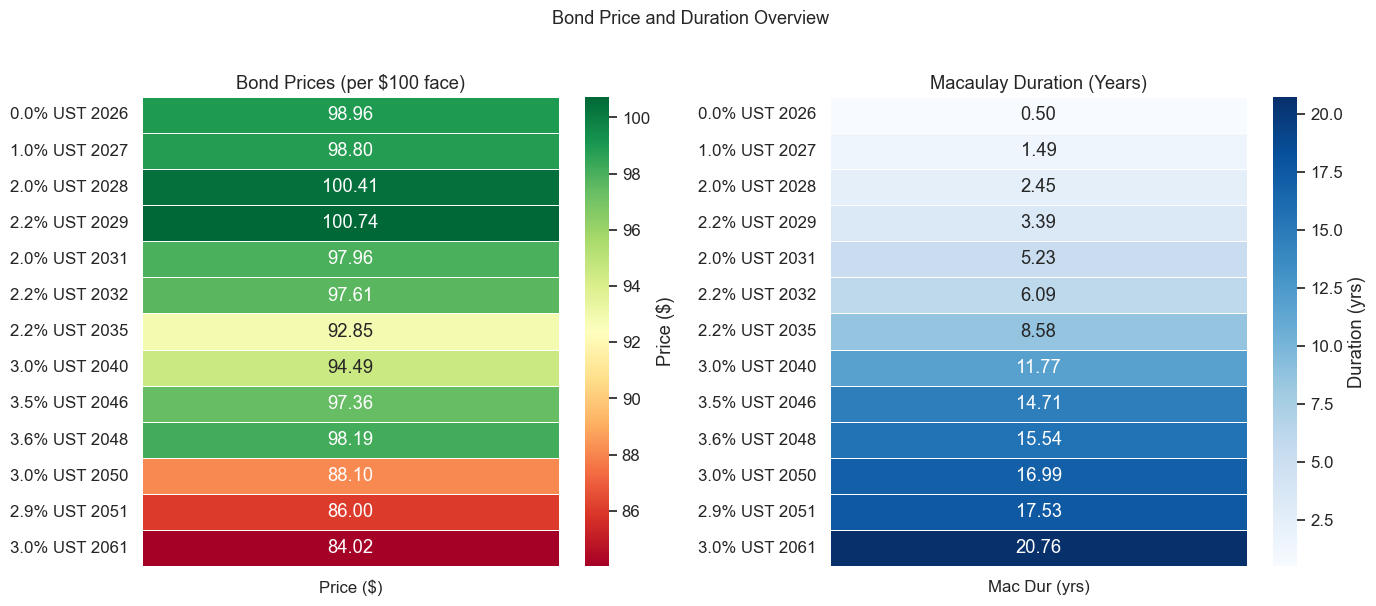

In [8]:
# Heatmap of prices and durations
heat = bond_res[['Bond','Price ($)','Mac Dur (yrs)','Mod Dur']].set_index('Bond')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.heatmap(heat[['Price ($)']], annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, ax=axes[0], cbar_kws={'label': 'Price ($)'})
axes[0].set_title('Bond Prices (per $100 face)')
axes[0].set_ylabel('')

sns.heatmap(heat[['Mac Dur (yrs)']], annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, ax=axes[1], cbar_kws={'label': 'Duration (yrs)'})
axes[1].set_title('Macaulay Duration (Years)')
axes[1].set_ylabel('')

plt.suptitle('Bond Price and Duration Overview', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## Section 5 — Yield Curve Scenario Analysis

| Scenario | What it means | How we model it |
|---|---|---|
| **+100 bps (Tightening)** | Fed raises rates | Shift entire curve up by 1% |
| **−100 bps (Easing)** | Rate cuts / recession | Shift entire curve down by 1% |
| **Steepening** | Short rates fall, long rates rise | Linear gradient across maturities |

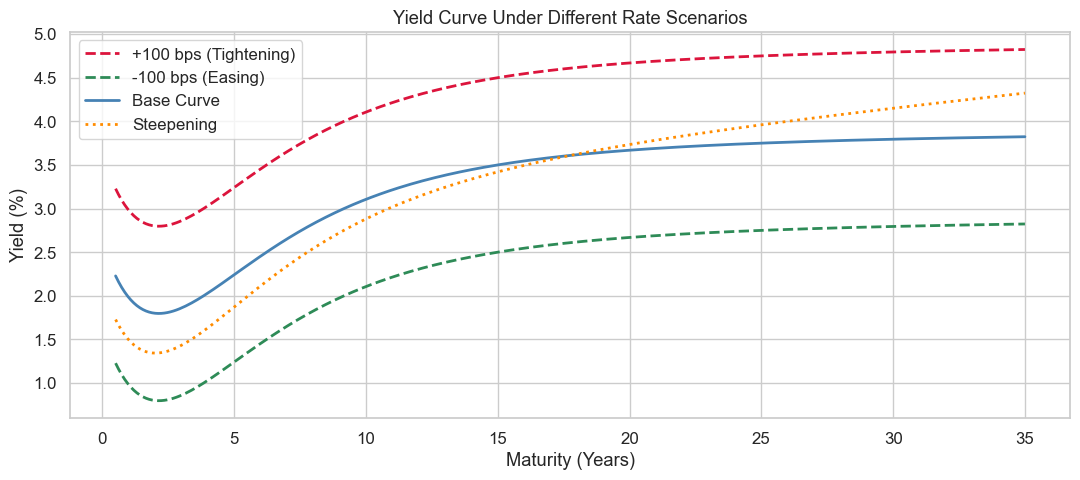

In [9]:
t_range = np.linspace(0.5, 35, 300)
base    = nss_yield(t_range, b0, b1, b2, b3, l1, l2)
up100   = base + 0.01
dn100   = base - 0.01
factor  = (t_range - t_range.min()) / (t_range.max() - t_range.min())
steep   = base + (-0.005 + 0.010 * factor)

scenario_df = pd.DataFrame({
    'Maturity': np.tile(t_range, 4),
    'Yield (%)': np.concatenate([base, up100, dn100, steep]) * 100,
    'Scenario': (['Base Curve']*300 + ['+100 bps (Tightening)']*300 +
                 ['-100 bps (Easing)']*300 + ['Steepening']*300)
})

palette = {'Base Curve':'steelblue', '+100 bps (Tightening)':'crimson',
           '-100 bps (Easing)':'seagreen', 'Steepening':'darkorange'}
styles  = {'Base Curve':'-', '+100 bps (Tightening)':'--',
           '-100 bps (Easing)':'--', 'Steepening':':'}

fig, ax = plt.subplots(figsize=(11, 5))
for scenario, grp in scenario_df.groupby('Scenario'):
    ax.plot(grp['Maturity'], grp['Yield (%)'],
            label=scenario, color=palette[scenario],
            linestyle=styles[scenario], linewidth=2)
ax.set_xlabel('Maturity (Years)')
ax.set_ylabel('Yield (%)')
ax.set_title('Yield Curve Under Different Rate Scenarios')
ax.legend()
plt.tight_layout()
plt.show()

---
## Section 6 — Bond Price Sensitivity
When rates rise, bond prices fall. Longer-duration bonds fall more.  
We reprice every bond under +100 bps and −100 bps and plot the % change.

In [10]:
shocks = {'+100 bps': 0.010, '-100 bps': -0.010, '+200 bps': 0.020}
sens_rows = []
for _, row in bonds.iterrows():
    ttm      = row['ttm']
    base_ytm = nss_yield(ttm, b0, b1, b2, b3, l1, l2)
    base_p   = bond_price(face, row['coupon'], base_ytm, ttm)
    entry    = {'Bond': row['label'], 'TTM': round(ttm,1), 'Base Price': round(base_p,2)}
    for label, shock in shocks.items():
        new_p = bond_price(face, row['coupon'], max(base_ytm + shock, 0.0001), ttm)
        entry[f'Pct ({label})'] = round((new_p - base_p) / base_p * 100, 2)
    sens_rows.append(entry)

sens_df = pd.DataFrame(sens_rows)
print(sens_df.to_string(index=False))

         Bond  TTM  Base Price  Pct (+100 bps)  Pct (-100 bps)  Pct (+200 bps)
0.0% UST 2026  0.7       98.96           -0.49            0.50           -0.98
1.0% UST 2027  1.7       98.80           -1.46            1.49           -2.90
2.0% UST 2028  2.7      100.41           -2.39            2.47           -4.72
2.2% UST 2029  3.7      100.74           -3.29            3.42           -6.45
2.0% UST 2031  5.7       97.96           -5.02            5.32           -9.76
2.2% UST 2032  6.7       97.61           -5.81            6.22          -11.24
2.2% UST 2035  9.7       92.85           -8.06            8.87          -15.40
3.0% UST 2040 14.7       94.49          -10.81           12.40          -20.26
3.5% UST 2046 20.7       97.36          -13.21           15.85          -24.25
3.6% UST 2048 22.7       98.19          -13.86           16.86          -25.29
3.0% UST 2050 24.7       88.10          -15.02           18.61          -27.20
2.9% UST 2051 25.7       86.00          -15.44      

/var/folders/y6/_p0sr96j2ys2_0bmp0597rm80000gn/T/ipykernel_79853/1330415077.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)


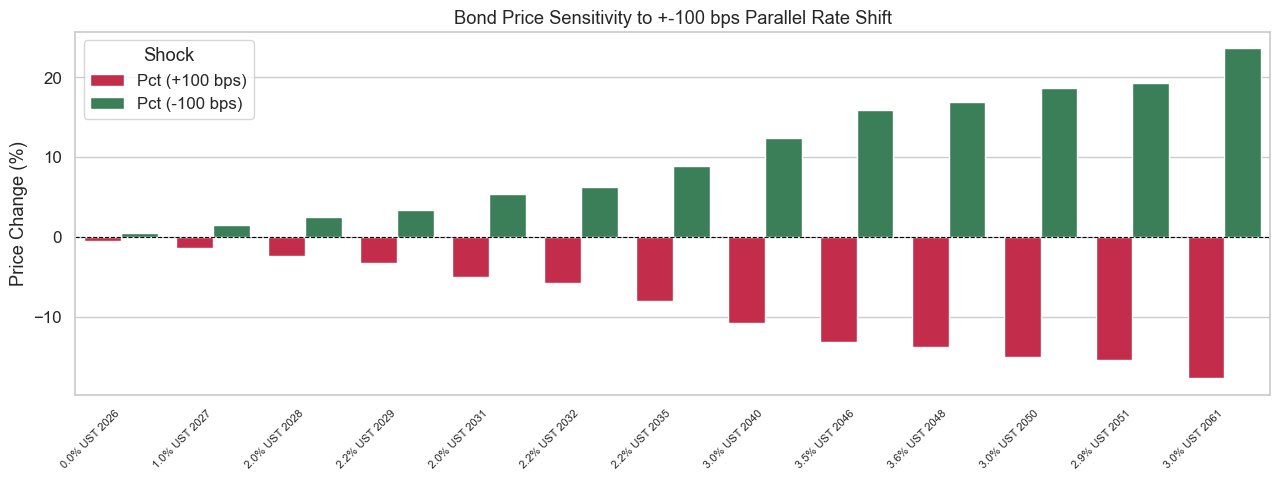

In [11]:
plot_data = sens_df[['Bond','Pct (+100 bps)','Pct (-100 bps)']].melt(
    id_vars='Bond', var_name='Scenario', value_name='Price Change (%)')

fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(data=plot_data, x='Bond', y='Price Change (%)', hue='Scenario',
            palette={'Pct (+100 bps)':'crimson','Pct (-100 bps)':'seagreen'}, ax=ax)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_title('Bond Price Sensitivity to +-100 bps Parallel Rate Shift')
ax.set_xlabel('')
ax.legend(title='Shock')
plt.tight_layout()
plt.show()

---
## Section 7 — Portfolio Recommendation ($50m USD)
Laddered portfolio: short bonds for liquidity, medium/long for yield pickup.  
*Adjust the weights below to match your group's recommendation.*

In [12]:
total_investment = 50_000_000

portfolio = [
    {'Bond': '0.0% UST 2026', 'Weight': 0.10},
    {'Bond': '1.0% UST 2027', 'Weight': 0.20},
    {'Bond': '2.0% UST 2028', 'Weight': 0.20},
    {'Bond': '2.2% UST 2029', 'Weight': 0.20},
    {'Bond': '2.2% UST 2032', 'Weight': 0.15},
    {'Bond': '3.0% UST 2040', 'Weight': 0.15},
]

port_df = pd.DataFrame(portfolio)
port_df['Price ($)'] = port_df['Bond'].map(bond_res.set_index('Bond')['Price ($)'])
port_df['Mac Dur']   = port_df['Bond'].map(bond_res.set_index('Bond')['Mac Dur (yrs)'])
port_df['YTM (%)']   = port_df['Bond'].map(bond_res.set_index('Bond')['YTM (%)'])
port_df['Invest ($)']= port_df['Weight'] * total_investment

port_duration = (port_df['Weight'] * port_df['Mac Dur']).sum()
port_yield    = (port_df['Weight'] * port_df['YTM (%)']).sum()

print(port_df[['Bond','Weight','Invest ($)','Price ($)','Mac Dur','YTM (%)']].to_string(index=False))
print(f'\nPortfolio Duration : {port_duration:.2f} yrs')
print(f'Weighted YTM       : {port_yield:.3f}%')

         Bond  Weight  Invest ($)  Price ($)  Mac Dur  YTM (%)
0.0% UST 2026    0.10   5000000.0    98.9640   0.5000    2.094
1.0% UST 2027    0.20  10000000.0    98.7968   1.4925    1.817
2.0% UST 2028    0.20  10000000.0   100.4135   2.4511    1.830
2.2% UST 2029    0.20  10000000.0   100.7383   3.3883    1.981
2.2% UST 2032    0.15   7500000.0    97.6144   6.0859    2.601
3.0% UST 2040    0.15   7500000.0    94.4947  11.7712    3.487

Portfolio Duration : 4.19 yrs
Weighted YTM       : 2.248%


/var/folders/y6/_p0sr96j2ys2_0bmp0597rm80000gn/T/ipykernel_79853/3531471112.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=port_df, x='Bond', y='Dur Contribution', palette='muted', ax=ax2)
/var/folders/y6/_p0sr96j2ys2_0bmp0597rm80000gn/T/ipykernel_79853/3531471112.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right', fontsize=8)


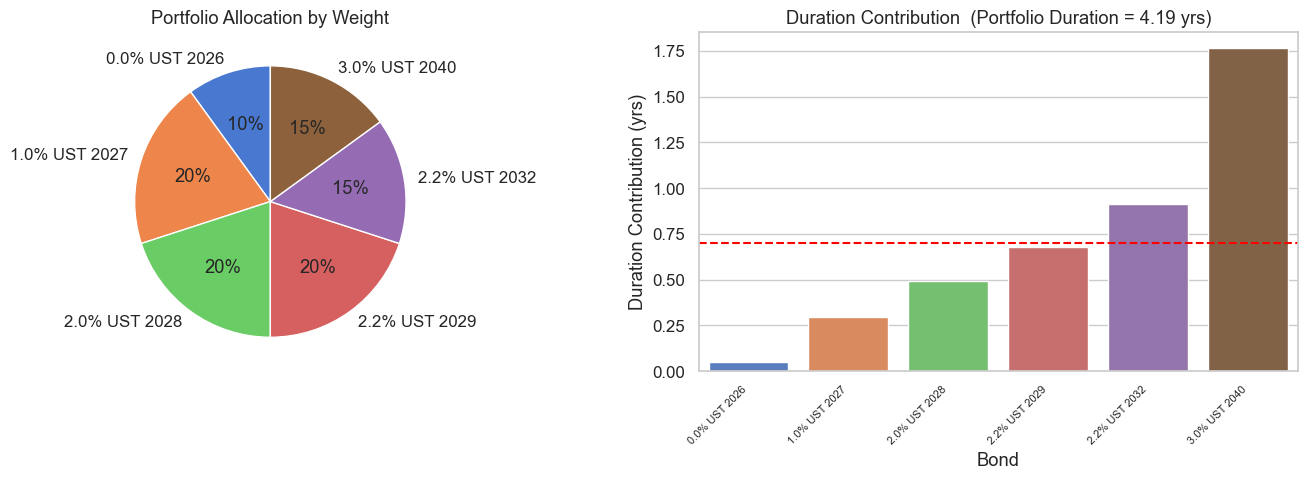

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = sns.color_palette('muted', len(port_df))
ax1.pie(port_df['Weight'], labels=port_df['Bond'], autopct='%1.0f%%',
        colors=colors, startangle=90)
ax1.set_title('Portfolio Allocation by Weight')

port_df['Dur Contribution'] = port_df['Weight'] * port_df['Mac Dur']
sns.barplot(data=port_df, x='Bond', y='Dur Contribution', palette='muted', ax=ax2)
ax2.axhline(port_duration / len(port_df), color='red', linestyle='--', linewidth=1.5)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax2.set_title(f'Duration Contribution  (Portfolio Duration = {port_duration:.2f} yrs)')
ax2.set_ylabel('Duration Contribution (yrs)')

plt.tight_layout()
plt.show()

---
## Section 8 — Immunisation Analysis

**Problem**: The client needs $8m in 2 years. Rate changes could cause the portfolio to be worth more or less than needed.

**Solution**: Build a portfolio with **Macaulay Duration = 2 years**.  
When duration matches the liability horizon, price risk and reinvestment risk cancel each other out.

**Method**: Pick two bonds — one with duration < 2 yrs, one with duration > 2 yrs — and solve for weights.
- **Bond A**: 1% UST 2027 (duration ~1.49 yrs)
- **Bond B**: 2% UST 2028 (duration ~2.45 yrs)

In [14]:
liability  = 8_000_000
target_dur = 2.0

bA = bond_res[bond_res['Bond'].str.contains('2027')].iloc[0]
bB = bond_res[bond_res['Bond'].str.contains('2028')].iloc[0]
D_A, D_B = bA['Mac Dur (yrs)'], bB['Mac Dur (yrs)']

# Solve: w_A*D_A + w_B*D_B = 2.0, w_A + w_B = 1
w_A = (D_B - target_dur) / (D_B - D_A)
w_B = 1 - w_A

ytm_2yr  = nss_yield(2.0, b0, b1, b2, b3, l1, l2)
pv_liab  = liability / (1 + ytm_2yr) ** 2
invest_A = w_A * pv_liab
invest_B = w_B * pv_liab
fv_A     = invest_A / (bA['Price ($)'] / 100)
fv_B     = invest_B / (bB['Price ($)'] / 100)

print('='*55)
print('  IMMUNISATION PORTFOLIO SUMMARY')
print('='*55)
print(f'  Liability Amount         : ${liability:>15,.0f}')
print(f'  2-Year NSS Yield         :  {ytm_2yr*100:.3f}%')
print(f'  PV of Liability (today)  : ${pv_liab:>15,.2f}')
print('-'*55)
print(f'  Bond A : {bA["Bond"]}')
print(f'    Weight                 :  {w_A*100:.2f}%')
print(f'    Amount to invest       : ${invest_A:>15,.2f}')
print(f'    Face value to buy      : ${fv_A:>15,.2f}')
print('-'*55)
print(f'  Bond B : {bB["Bond"]}')
print(f'    Weight                 :  {w_B*100:.2f}%')
print(f'    Amount to invest       : ${invest_B:>15,.2f}')
print(f'    Face value to buy      : ${fv_B:>15,.2f}')
print('='*55)
print(f'  Portfolio Duration       :  {w_A*D_A+w_B*D_B:.4f} yrs (target = 2.0)')
print('='*55)

  IMMUNISATION PORTFOLIO SUMMARY
  Liability Amount         : $      8,000,000
  2-Year NSS Yield         :  1.800%
  PV of Liability (today)  : $   7,719,618.30
-------------------------------------------------------
  Bond A : 1.0% UST 2027
    Weight                 :  47.06%
    Amount to invest       : $   3,632,714.18
    Face value to buy      : $   3,676,955.31
-------------------------------------------------------
  Bond B : 2.0% UST 2028
    Weight                 :  52.94%
    Amount to invest       : $   4,086,904.12
    Face value to buy      : $   4,070,074.36
  Portfolio Duration       :  2.0000 yrs (target = 2.0)


In [15]:
# Stress test the immunisation
row_A  = bonds[bonds['maturity_year'] == 2027].iloc[0]
row_B  = bonds[bonds['maturity_year'] == 2028].iloc[0]
ttm_A  = bA['TTM (yrs)']
ttm_B  = bB['TTM (yrs)']

stress_rows = []
for shock in [-0.02, -0.01, 0.00, +0.01, +0.02]:
    pA  = bond_price(face, row_A['coupon'], max(nss_yield(ttm_A,b0,b1,b2,b3,l1,l2)+shock,0.0001), ttm_A)
    pB  = bond_price(face, row_B['coupon'], max(nss_yield(ttm_B,b0,b1,b2,b3,l1,l2)+shock,0.0001), ttm_B)
    pv  = (fv_A/100*pA) + (fv_B/100*pB)
    pvl = liability / (1 + nss_yield(2.0,b0,b1,b2,b3,l1,l2) + shock) ** 2
    stress_rows.append({'Shock (bps)': int(shock*10000), 'Port Value': round(pv,2),
                        'Liability PV': round(pvl,2), 'Surplus': round(pv-pvl,2),
                        'Covered?': 'YES' if pv >= pvl else 'NO'})

stress_df = pd.DataFrame(stress_rows)
print(stress_df.to_string(index=False))

 Shock (bps)  Port Value  Liability PV   Surplus Covered?
        -200  8004082.82    8032122.59 -28039.77       NO
        -100  7874636.82    7873545.34   1091.49      YES
           0  7719622.08    7719618.30      3.79      YES
         100  7568602.33    7570161.42  -1559.09       NO
         200  7421452.24    7425003.26  -3551.02       NO


/var/folders/y6/_p0sr96j2ys2_0bmp0597rm80000gn/T/ipykernel_79853/926332387.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stress_df, x='Shock (bps)', y='Surplus', palette=bar_colors, ax=ax)


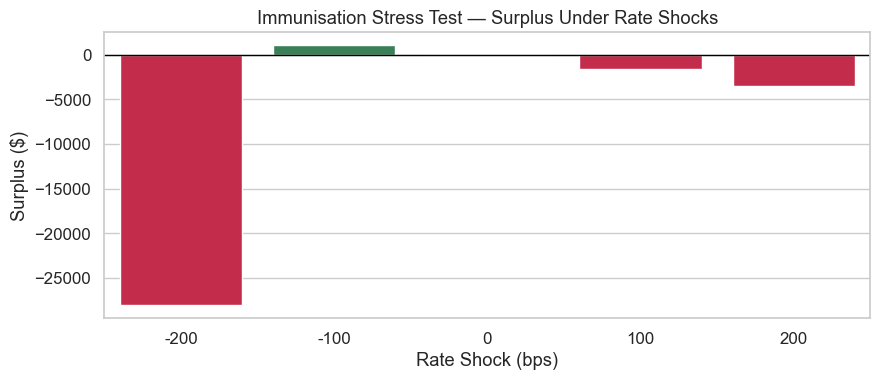

In [16]:
fig, ax = plt.subplots(figsize=(9, 4))
bar_colors = ['seagreen' if s >= 0 else 'crimson' for s in stress_df['Surplus']]
sns.barplot(data=stress_df, x='Shock (bps)', y='Surplus', palette=bar_colors, ax=ax)
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Immunisation Stress Test — Surplus Under Rate Shocks')
ax.set_xlabel('Rate Shock (bps)')
ax.set_ylabel('Surplus ($)')
plt.tight_layout()
plt.show()

---
## Section 9 — Full Summary Table

In [17]:
summary = bond_res.copy()
summary['Pct (+100bps)'] = sens_df['Pct (+100 bps)'].values
summary['Pct (-100bps)'] = sens_df['Pct (-100 bps)'].values
print(summary.to_string(index=False))

         Bond  TTM (yrs)  YTM (%)  Price ($)  Mac Dur (yrs)  Mod Dur  Pct (+100bps)  Pct (-100bps)
0.0% UST 2026       0.74    2.094    98.9640         0.5000   0.4948          -0.49           0.50
1.0% UST 2027       1.74    1.817    98.7968         1.4925   1.4791          -1.46           1.49
2.0% UST 2028       2.74    1.830   100.4135         2.4511   2.4289          -2.39           2.47
2.2% UST 2029       3.74    1.981   100.7383         3.3883   3.3551          -3.29           3.42
2.0% UST 2031       5.74    2.399    97.9571         5.2322   5.1702          -5.02           5.32
2.2% UST 2032       6.74    2.601    97.6144         6.0859   6.0078          -5.81           6.22
2.2% UST 2035       9.74    3.074    92.8467         8.5830   8.4531          -8.06           8.87
3.0% UST 2040      14.74    3.487    94.4947        11.7712  11.5695         -10.81          12.40
3.5% UST 2046      20.74    3.685    97.3615        14.7083  14.4423         -13.21          15.85
3.6% UST 2